# Bow-Tie Optical Cavity — Gaussian Beam Eigenmode

## Purpose

This notebook models a **four-mirror passive bow-tie optical cavity** at 1064 nm using paraxial ABCD/Gaussian-beam optics.

The goal is to determine and visualize the self-consistent Gaussian eigenmode of the cavity, including the difference between the **tangential** and **sagittal** planes produced by oblique incidence on the curved mirrors.

This notebook contains **no nonlinear crystal, nonlinear interaction, squeezing calculation, or pump field**. It is the passive bow-tie cavity model only.

The notebook develops the calculation step by step:

1. Define the cavity geometry and optical elements.
2. Construct tangential and sagittal ABCD matrices.
3. Determine cavity stability.
4. Solve for the self-consistent complex beam parameter $q$.
5. Propagate $q$ through each cavity section and verify round-trip closure.
6. Calculate beam radii at the mirrors and along the cavity.
7. Visualize the Gaussian mode using 1D beam-radius plots, a 2D beam-envelope plot, and a transverse Gaussian intensity map.

> **Modeling convention:** the reference plane is immediately after reflection from M1, and the physical sequence is M1 → M2 → M3 → M4 → M1.

## 1. Physical and geometrical parameters

We use

$$
\lambda_0 = 1064\ \mathrm{nm},
$$

with an angle of incidence

$$
\theta = 12^\circ.
$$

The cavity has two curved mirrors and two flat mirrors:

- M1 and M2: spherical mirrors with $R=38$ mm.
- M3 and M4: flat mirrors, $R\rightarrow\infty$.

The chosen free-space distances are

$$
 d_1=40\ \mathrm{mm},
 \qquad d_3=90\ \mathrm{mm}.
$$

For the folded arms we use

$$
 d_2=d_4=\frac{d_1+d_3}{2\cos\theta}.
$$

With the present geometry this gives approximately

$$
 d_2=d_4=66.452\ \mathrm{mm},
$$

and the round-trip geometrical length is

$$
L_{\rm rt}=d_1+d_2+d_3+d_4
\approx262.904\ \mathrm{mm}.
$$

**Important:** these are geometrical propagation distances used in the present ABCD model. They should not automatically be interpreted as optical path lengths through a material; no material is present in this passive model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
c = 299792458.0
lambda_0 = 1064e-9  # wavelength (m)

# Cavity geometry
theta = np.deg2rad(12)

d_1 = 40.0e-3  # M1 -> M2 (m)
d_3 = 90.0e-3  # M3 -> M4 (m)

# Oblique folding distances
d_2 = (d_1 + d_3) / (2 * np.cos(theta))
d_4 = d_2

# Total round-trip geometrical length
L_rt = d_1 + d_2 + d_3 + d_4

# Mirror radii of curvature
ROC_1 = 0.038
ROC_2 = 0.038
ROC_3 = np.inf
ROC_4 = np.inf

print(f"Total round-trip distance L_rt = {L_rt*1e3:.2f} mm")
print(f"d1 = {d_1*1e3:.2f} mm")
print(f"d2 = {d_2*1e3:.2f} mm")
print(f"d3 = {d_3*1e3:.2f} mm")
print(f"d4 = {d_4*1e3:.2f} mm")

Total round-trip distance L_rt = 262.90 mm
d1 = 40.00 mm
d2 = 66.45 mm
d3 = 90.00 mm
d4 = 66.45 mm


## 2. ABCD matrices and the complex beam parameter

For free-space propagation over a distance $d$,

$$
P(d)=
\begin{pmatrix}
1 & d\\
0 & 1
\end{pmatrix}.
$$

For reflection from a spherical mirror of radius $R$, using the paraxial mirror convention adopted here,

$$
M(R)=
\begin{pmatrix}
1 & 0\\
-2/R & 1
\end{pmatrix}.
$$

At oblique incidence, a spherical mirror has different effective curvatures in the two transverse planes. We therefore treat the tangential and sagittal planes separately:

$$
R_t=R\cos\theta,
$$

$$
R_s=\frac{R}{\cos\theta}.
$$

Thus the same physical curved mirror has different focusing powers in the two planes. This is the origin of the astigmatism represented in this model.

The complex Gaussian beam parameter is defined by

$$
\frac{1}{q}=\frac{1}{R_c}-i\frac{\lambda}{\pi w^2},
$$

and transforms under an ABCD matrix as

$$
q' = \frac{Aq+B}{Cq+D}.
$$

In [2]:
# Free-space propagation matrix
def P(d):
    return np.array([[1.0, d], [0.0, 1.0]])

# Tangential-plane mirror matrix
def M_t(R, theta=0.0):
    if np.isinf(R):
        return np.eye(2)
    R_t = R * np.cos(theta)
    return np.array([[1.0, 0.0], [-2.0 / R_t, 1.0]])

# Sagittal-plane mirror matrix
def M_s(R, theta=0.0):
    if np.isinf(R):
        return np.eye(2)
    R_s = R / np.cos(theta)
    return np.array([[1.0, 0.0], [-2.0 / R_s, 1.0]])

def get_ABCD(matrix):
    return matrix.flatten()

def propagate_q(q, matrix):
    A, B, C, D = get_ABCD(matrix)
    return (A * q + B) / (C * q + D)

def beam_radius(q, wavelength):
    return np.sqrt(-wavelength / (np.pi * (1.0 / q).imag))

## 3. Round-trip ABCD matrices and cavity stability

The physical sequence is

$$
M_1\rightarrow P_1\rightarrow M_2\rightarrow P_2\rightarrow M_3\rightarrow P_3\rightarrow M_4\rightarrow P_4\rightarrow M_1.
$$

Because the system is astigmatic, we construct one round-trip matrix for each transverse plane.

For a real first-order optical system with unit determinant, the stability criterion can be written in terms of

$$
 g_{\rm rt}=\frac{A+D}{2}.
$$

The cavity is stable when

$$
|g_{\rm rt}|<1.
$$

In [3]:
# Free-space matrices
P_1, P_2, P_3, P_4 = P(d_1), P(d_2), P(d_3), P(d_4)

# Mirror matrices
M_1_t, M_2_t, M_3_t, M_4_t = (
    M_t(ROC_1, theta), M_t(ROC_2, theta), M_t(ROC_3, theta), M_t(ROC_4, theta)
)
M_1_s, M_2_s, M_3_s, M_4_s = (
    M_s(ROC_1, theta), M_s(ROC_2, theta), M_s(ROC_3, theta), M_s(ROC_4, theta)
)

M_rt_t = M_1_t @ P_4 @ M_4_t @ P_3 @ M_3_t @ P_2 @ M_2_t @ P_1
M_rt_s = M_1_s @ P_4 @ M_4_s @ P_3 @ M_3_s @ P_2 @ M_2_s @ P_1

A_t, B_t, C_t, D_t = get_ABCD(M_rt_t)
A_s, B_s, C_s, D_s = get_ABCD(M_rt_s)

g_rt_t = (A_t + D_t) / 2.0
g_rt_s = (A_s + D_s) / 2.0

print(f"Tangential g_t = {g_rt_t:.6f} | Stable? {abs(g_rt_t) < 1}")
print(f"Sagittal   g_s = {g_rt_s:.6f} | Stable? {abs(g_rt_s) < 1}")
print(f"Det(M_rt_t) = {np.linalg.det(M_rt_t):.12f}")
print(f"Det(M_rt_s) = {np.linalg.det(M_rt_s):.12f}")

Tangential g_t = -0.238985 | Stable? True
Sagittal   g_s = -0.719252 | Stable? True
Det(M_rt_t) = 1.000000000000
Det(M_rt_s) = 1.000000000000


### Result: stable passive bow-tie cavity

For the chosen geometry,

$$
 g_t\approx-0.238985,
\qquad
 g_s\approx-0.719252.
$$

Both satisfy $|g|<1$, so the tangential and sagittal eigenmodes are stable.

The calculated round-trip matrices also have determinant approximately equal to one, as expected for the lossless first-order ABCD description used here.

## 4. Self-consistent Gaussian eigenmode

For the cavity eigenmode, the beam parameter must reproduce itself after one round trip:

$$
q=\frac{Aq+B}{Cq+D}.
$$

Rearranging gives

$$
Cq^2+(D-A)q-B=0.
$$

This is a quadratic equation for the complex eigenmode parameter $q$.

The physical Gaussian-beam solution is the root with

$$
\operatorname{Im}(q)>0,
$$

because

$$
\operatorname{Im}\left(\frac{1}{q}\right)<0
$$

is required for a real positive beam radius.

In [4]:
def solve_q_eigenmode(matrix):
    """Solve C*q^2 + (D-A)*q - B = 0 and return the root with Im(q) > 0."""
    A, B, C, D = get_ABCD(matrix)
    roots = np.roots([C, D - A, -B])

    for q in roots:
        if q.imag > 0:
            return q

    raise ValueError("No physical eigenmode found; the cavity may be unstable.")

q_1_t = solve_q_eigenmode(M_rt_t)
q_1_s = solve_q_eigenmode(M_rt_s)

w_1_t = beam_radius(q_1_t, lambda_0)
w_1_s = beam_radius(q_1_s, lambda_0)

print("Complex beam parameter q at the reference plane (immediately after M1)")
print(f"Tangential q = {q_1_t:.6f} m")
print(f"Sagittal q   = {q_1_s:.6f} m")
print()
print(f"Tangential beam radius at M1 = {w_1_t*1e6:.2f} μm")
print(f"Sagittal beam radius at M1   = {w_1_s*1e6:.2f} μm")

Complex beam parameter q at the reference plane (immediately after M1)
Tangential q = -0.020000+0.001806j m
Sagittal q   = -0.020000+0.001424j m

Tangential beam radius at M1 = 275.02 μm
Sagittal beam radius at M1   = 309.20 μm


### Eigenmode at M1

The numerical solution is

$$
q_{1,t}\approx-0.020000+i\,0.001806\ \mathrm m,
$$

$$
q_{1,s}\approx-0.020000+i\,0.001424\ \mathrm m.
$$

Writing

$$
q=z+i z_R,
$$

we interpret $\operatorname{Re}(q)$ as the distance from the beam waist and $\operatorname{Im}(q)=z_R$ as the Rayleigh range.

Therefore $\operatorname{Re}(q_1)=-20$ mm means that the first waist is 20 mm after M1. Since M1–M2 is 40 mm long, this waist lies at the midpoint of the M1–M2 arm for the present geometry.

The waist radii follow from

$$
 w_0=\sqrt{\frac{\lambda z_R}{\pi}}.
$$

In [5]:
w0_t = np.sqrt(lambda_0 * q_1_t.imag / np.pi)
w0_s = np.sqrt(lambda_0 * q_1_s.imag / np.pi)

print(f"First waist tangential radius = {w0_t*1e6:.2f} μm")
print(f"First waist sagittal radius   = {w0_s*1e6:.2f} μm")

First waist tangential radius = 24.73 μm
First waist sagittal radius   = 21.96 μm


## 5. Propagating the eigenmode around the cavity

We now propagate the same eigenmode through the actual physical sequence, one optical element at a time.

This is useful because the round-trip matrix gives the eigenmode efficiently, while explicit propagation lets us inspect what happens inside each arm of the cavity.

In [6]:
# M1 -> M2
q_2_t = propagate_q(q_1_t, P_1)
q_2_s = propagate_q(q_1_s, P_1)

# Reflection from M2
q_2_after_t = propagate_q(q_2_t, M_2_t)
q_2_after_s = propagate_q(q_2_s, M_2_s)

# M2 -> M3
q_3_t = propagate_q(q_2_after_t, P_2)
q_3_s = propagate_q(q_2_after_s, P_2)

# Reflection from flat M3
q_3_after_t = propagate_q(q_3_t, M_3_t)
q_3_after_s = propagate_q(q_3_s, M_3_s)

# M3 -> M4
q_4_t = propagate_q(q_3_after_t, P_3)
q_4_s = propagate_q(q_3_after_s, P_3)

# Reflection from flat M4
q_4_after_t = propagate_q(q_4_t, M_4_t)
q_4_after_s = propagate_q(q_4_s, M_4_s)

# M4 -> M1
q_1_before_t = propagate_q(q_4_after_t, P_4)
q_1_before_s = propagate_q(q_4_after_s, P_4)

# Reflection from M1
q_1_after_t = propagate_q(q_1_before_t, M_1_t)
q_1_after_s = propagate_q(q_1_before_s, M_1_s)

print("q at key points around the cavity")
print(f"M2 before reflection: t={q_2_t:.6f}, s={q_2_s:.6f}")
print(f"M2 after reflection:  t={q_2_after_t:.6f}, s={q_2_after_s:.6f}")
print(f"M3:                  t={q_3_t:.6f}, s={q_3_s:.6f}")
print(f"M4:                  t={q_4_t:.6f}, s={q_4_s:.6f}")
print(f"M1 before reflection: t={q_1_before_t:.6f}, s={q_1_before_s:.6f}")

q at key points around the cavity
M2 before reflection: t=0.020000+0.001806j, s=0.020000+0.001424j
M2 after reflection:  t=-0.111452+0.118495j, s=-0.111452+0.227735j
M3:                  t=-0.045000+0.118495j, s=-0.045000+0.227735j
M4:                  t=0.045000+0.118495j, s=0.045000+0.227735j
M1 before reflection: t=0.111452+0.118495j, s=0.111452+0.227735j


### Round-trip closure

Because this is a self-consistent cavity eigenmode, propagating the beam around the complete cavity and reflecting from M1 again must reproduce the starting $q$.

We compare the numerical complex values using `np.isclose()` rather than exact `==`, because floating-point arithmetic does not generally produce bit-for-bit identical results.

In [7]:
if np.isclose(q_1_after_t, q_1_t) and np.isclose(q_1_after_s, q_1_s):
    print("Round-trip q closure verified: the eigenmode reproduces itself.")
else:
    print("Round-trip q closure failed.")

Round-trip q closure verified: the eigenmode reproduces itself.


## 6. Beam radius at the four mirrors

The beam radius is obtained from $q$ through

$$
 w=\sqrt{-\frac{\lambda}{\pi\,\operatorname{Im}(1/q)}}.
$$

For the present geometry, the mirror beam radii are:

In [8]:
w_2_t = beam_radius(q_2_t, lambda_0)
w_2_s = beam_radius(q_2_s, lambda_0)
w_3_t = beam_radius(q_3_t, lambda_0)
w_3_s = beam_radius(q_3_s, lambda_0)
w_4_t = beam_radius(q_4_t, lambda_0)
w_4_s = beam_radius(q_4_s, lambda_0)

print(f"M1: tangential = {w_1_t*1e6:.2f} μm, sagittal = {w_1_s*1e6:.2f} μm")
print(f"M2: tangential = {w_2_t*1e6:.2f} μm, sagittal = {w_2_s*1e6:.2f} μm")
print(f"M3: tangential = {w_3_t*1e6:.2f} μm, sagittal = {w_3_s*1e6:.2f} μm")
print(f"M4: tangential = {w_4_t*1e6:.2f} μm, sagittal = {w_4_s*1e6:.2f} μm")

M1: tangential = 275.02 μm, sagittal = 309.20 μm
M2: tangential = 275.02 μm, sagittal = 309.20 μm
M3: tangential = 214.29 μm, sagittal = 283.09 μm
M4: tangential = 214.29 μm, sagittal = 283.09 μm


For the present cavity,

- M1/M2: $w_t\approx275.02\ \mu$m and $w_s\approx309.20\ \mu$m.
- M3/M4: $w_t\approx214.29\ \mu$m and $w_s\approx283.09\ \mu$m.

The tangential and sagittal radii differ because the oblique curved mirrors have different effective curvatures in the two planes.

## 7. Continuous beam evolution around the cavity

We now sample each free-space segment with 250 points. The coordinate $s$ is a **global longitudinal coordinate** around the cavity.

When propagating within a segment, the quantity supplied to $P(d)$ is the **local distance travelled from the beginning of that segment**, such as $s-s_{M2}$ for M2 → M3.

In [9]:
# Global cavity coordinates
s_M1 = 0.0
s_M2 = s_M1 + d_1
s_M3 = s_M2 + d_2
s_M4 = s_M3 + d_3
s_end = s_M4 + d_4

# 250 points per propagation segment
s_1 = np.linspace(s_M1, s_M2, 250)
s_2 = np.linspace(s_M2, s_M3, 250)
s_3 = np.linspace(s_M3, s_M4, 250)
s_4 = np.linspace(s_M4, s_end, 250)

print(f"M1: {s_M1*1e3:.2f} mm")
print(f"M2: {s_M2*1e3:.2f} mm")
print(f"M3: {s_M3*1e3:.2f} mm")
print(f"M4: {s_M4*1e3:.2f} mm")
print(f"End of round trip: {s_end*1e3:.2f} mm")

M1: 0.00 mm
M2: 40.00 mm
M3: 106.45 mm
M4: 196.45 mm
End of round trip: 262.90 mm


In [10]:
def beam_radius_array(q_array, wavelength):
    """Calculate Gaussian beam radius for an array of q parameters."""
    return np.array([beam_radius(q, wavelength) for q in q_array])

# q(s) in each segment
q_1_segment_t = np.array([propagate_q(q_1_t, P(s - s_M1)) for s in s_1])
q_1_segment_s = np.array([propagate_q(q_1_s, P(s - s_M1)) for s in s_1])

q_2_segment_t = np.array([propagate_q(q_2_after_t, P(s - s_M2)) for s in s_2])
q_2_segment_s = np.array([propagate_q(q_2_after_s, P(s - s_M2)) for s in s_2])

q_3_segment_t = np.array([propagate_q(q_3_after_t, P(s - s_M3)) for s in s_3])
q_3_segment_s = np.array([propagate_q(q_3_after_s, P(s - s_M3)) for s in s_3])

q_4_segment_t = np.array([propagate_q(q_4_after_t, P(s - s_M4)) for s in s_4])
q_4_segment_s = np.array([propagate_q(q_4_after_s, P(s - s_M4)) for s in s_4])

# Beam-radius arrays
w_1_segment_t = beam_radius_array(q_1_segment_t, lambda_0)
w_1_segment_s = beam_radius_array(q_1_segment_s, lambda_0)
w_2_segment_t = beam_radius_array(q_2_segment_t, lambda_0)
w_2_segment_s = beam_radius_array(q_2_segment_s, lambda_0)
w_3_segment_t = beam_radius_array(q_3_segment_t, lambda_0)
w_3_segment_s = beam_radius_array(q_3_segment_s, lambda_0)
w_4_segment_t = beam_radius_array(q_4_segment_t, lambda_0)
w_4_segment_s = beam_radius_array(q_4_segment_s, lambda_0)

### M1 → M2

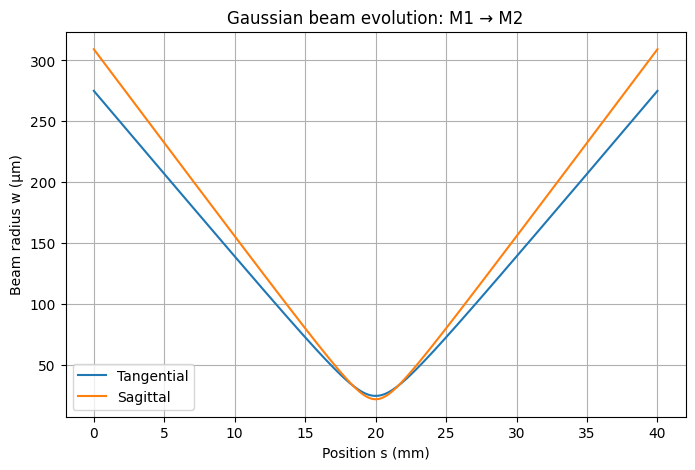

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(s_1*1e3, w_1_segment_t*1e6, label="Tangential")
plt.plot(s_1*1e3, w_1_segment_s*1e6, label="Sagittal")
plt.xlabel("Position s (mm)")
plt.ylabel("Beam radius w (μm)")
plt.title("Gaussian beam evolution: M1 → M2")
plt.legend()
plt.grid(True)
plt.show()

### M2 → M3

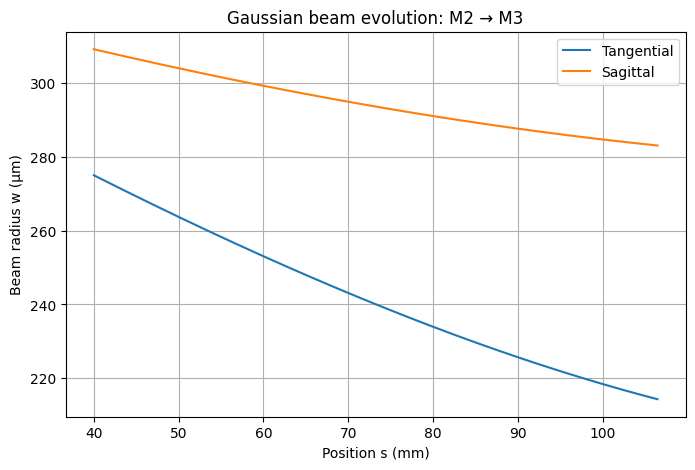

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(s_2*1e3, w_2_segment_t*1e6, label="Tangential")
plt.plot(s_2*1e3, w_2_segment_s*1e6, label="Sagittal")
plt.xlabel("Position s (mm)")
plt.ylabel("Beam radius w (μm)")
plt.title("Gaussian beam evolution: M2 → M3")
plt.legend()
plt.grid(True)
plt.show()

### M3 → M4

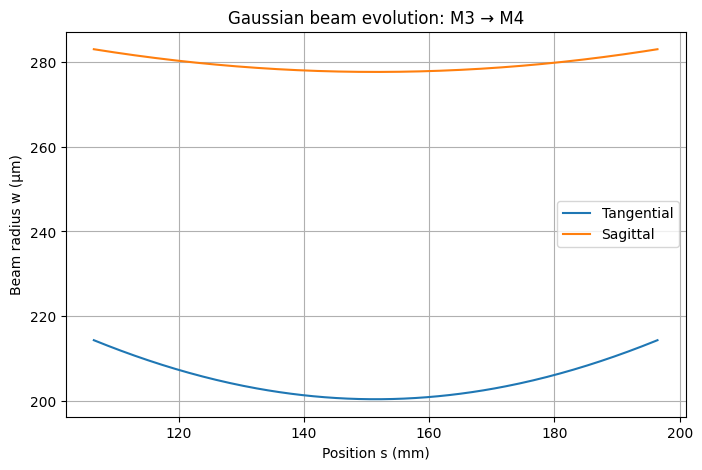

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(s_3*1e3, w_3_segment_t*1e6, label="Tangential")
plt.plot(s_3*1e3, w_3_segment_s*1e6, label="Sagittal")
plt.xlabel("Position s (mm)")
plt.ylabel("Beam radius w (μm)")
plt.title("Gaussian beam evolution: M3 → M4")
plt.legend()
plt.grid(True)
plt.show()

### M4 → M1

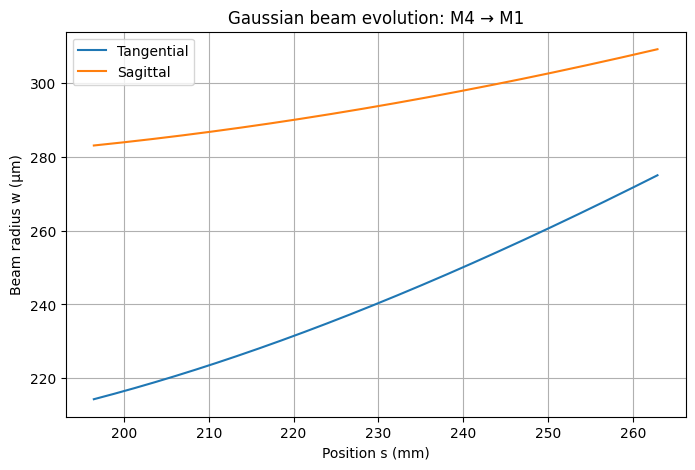

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(s_4*1e3, w_4_segment_t*1e6, label="Tangential")
plt.plot(s_4*1e3, w_4_segment_s*1e6, label="Sagittal")
plt.xlabel("Position s (mm)")
plt.ylabel("Beam radius w (μm)")
plt.title("Gaussian beam evolution: M4 → M1")
plt.legend()
plt.grid(True)
plt.show()

## 8. Complete cavity beam profile

The four segments are joined into a single global coordinate. The first point of each later segment is omitted so that the shared mirror positions are not duplicated.

In [15]:
s_full = np.concatenate([s_1, s_2[1:], s_3[1:], s_4[1:]])
q_full_t = np.concatenate([q_1_segment_t, q_2_segment_t[1:], q_3_segment_t[1:], q_4_segment_t[1:]])
q_full_s = np.concatenate([q_1_segment_s, q_2_segment_s[1:], q_3_segment_s[1:], q_4_segment_s[1:]])
w_full_t = np.concatenate([w_1_segment_t, w_2_segment_t[1:], w_3_segment_t[1:], w_4_segment_t[1:]])
w_full_s = np.concatenate([w_1_segment_s, w_2_segment_s[1:], w_3_segment_s[1:], w_4_segment_s[1:]])

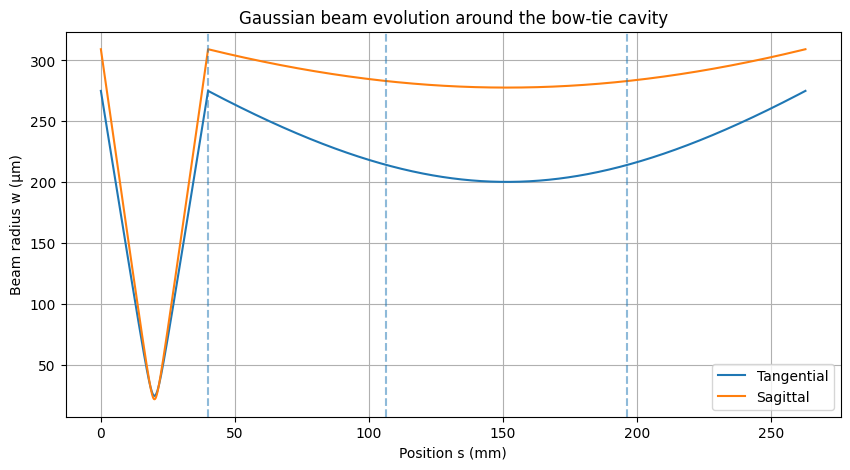

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(s_full*1e3, w_full_t*1e6, label="Tangential")
plt.plot(s_full*1e3, w_full_s*1e6, label="Sagittal")

for s_mirror in [s_M2, s_M3, s_M4]:
    plt.axvline(s_mirror*1e3, linestyle="--", alpha=0.5)

plt.xlabel("Position s (mm)")
plt.ylabel("Beam radius w (μm)")
plt.title("Gaussian beam evolution around the bow-tie cavity")
plt.legend()
plt.grid(True)
plt.show()

For the present geometry, the first waist occurs about 20 mm after M1. The second waist occurs about halfway along M3 → M4, around 151.45 mm in the global cavity coordinate.

These locations are properties of the **current geometry**. We intentionally do not build automatic waist detection into the model here; the plotted $w(s)$ profile is sufficient for visual inspection, and later models can introduce a dedicated waist-location calculation if it becomes physically necessary.

## 9. Transverse Gaussian intensity at a selected cavity position

At a chosen longitudinal position, the transverse intensity profile of the astigmatic Gaussian mode is represented by

$$
I(x,y;s)=I_0(s)\exp\left[-2\left(\frac{x^2}{w_t(s)^2}+\frac{y^2}{w_s(s)^2}\right)\right].
$$

Here $w_t$ and $w_s$ are the tangential and sagittal $1/e^2$ intensity radii. Because they are different, the transverse profile is generally elliptical rather than circular.

For visualization we normalize the peak intensity to $I_0=1$.

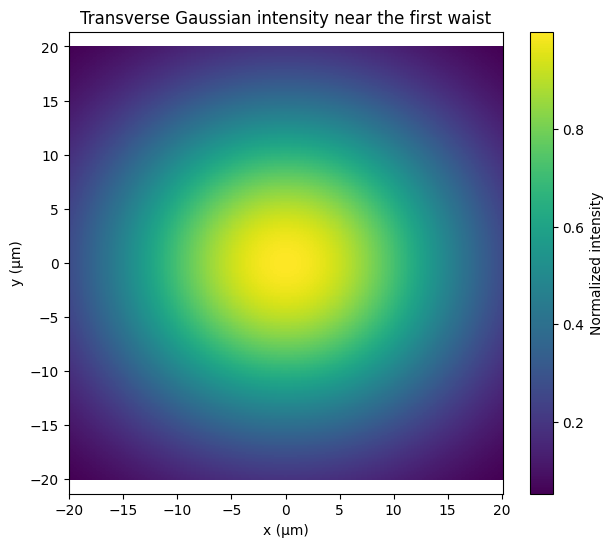

In [17]:
# Transverse grid around the first waist
x = np.linspace(-20e-6, 20e-6, 300)
y = np.linspace(-20e-6, 20e-6, 300)
X, Y = np.meshgrid(x, y)

# Use the sampled point closest to the first-waist location (20 mm)
waist_sample_index = np.argmin(np.abs(s_1 - 20e-3))
w_t = w_1_segment_t[waist_sample_index]
w_s = w_1_segment_s[waist_sample_index]

I = np.exp(-2 * (X**2 / w_t**2 + Y**2 / w_s**2))

plt.figure(figsize=(7, 6))
plt.pcolormesh(X*1e6, Y*1e6, I, shading="auto")
plt.xlabel("x (μm)")
plt.ylabel("y (μm)")
plt.title("Transverse Gaussian intensity near the first waist")
plt.colorbar(label="Normalized intensity")
plt.axis("equal")
plt.show()

The transverse map makes the astigmatism visible directly: the tangential and sagittal waist radii are slightly different,

$$
 w_{0,t}\approx24.73\ \mu\mathrm m,
\qquad
 w_{0,s}\approx21.96\ \mu\mathrm m.
$$

## 10. Two-dimensional beam-envelope view

A useful side-view visualization is obtained by plotting the $\pm w(s)$ boundaries. This is not a hard physical boundary—the Gaussian field extends indefinitely—but the $w$ contour is the conventional $1/e^2$ intensity radius.

Plotting both transverse-plane envelopes in the same figure gives an intuitive view of how the beam converges, reaches its waists, and diverges around the cavity.

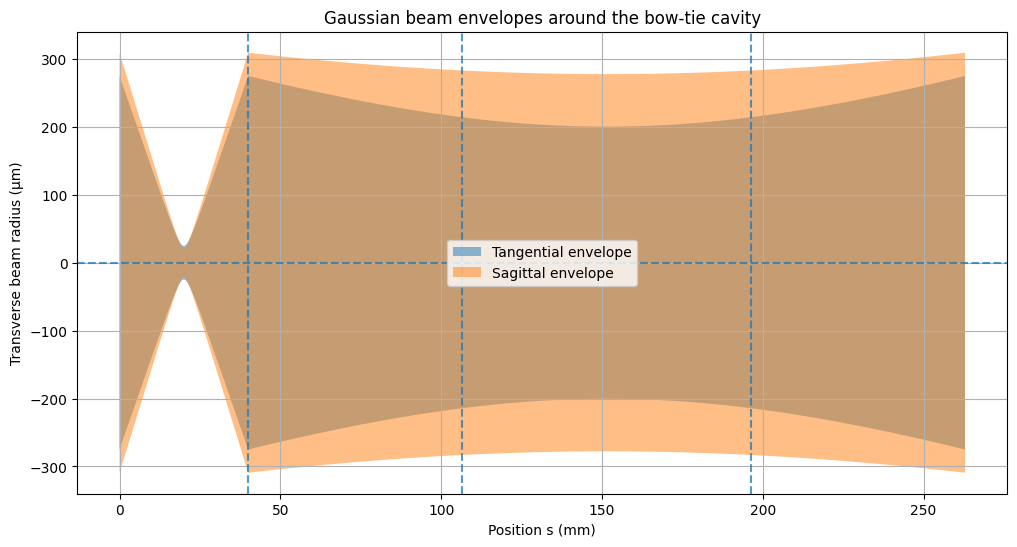

In [18]:
plt.figure(figsize=(12, 6))

plt.fill_between(
    s_full*1e3, -w_full_t*1e6, +w_full_t*1e6,
    alpha=0.5, label="Tangential envelope"
)

plt.fill_between(
    s_full*1e3, -w_full_s*1e6, +w_full_s*1e6,
    alpha=0.5, label="Sagittal envelope"
)

plt.axhline(0, linestyle="--", alpha=0.75)

for s_mirror in [s_M2, s_M3, s_M4]:
    plt.axvline(s_mirror*1e3, linestyle="--", alpha=0.75)

plt.xlabel("Position s (mm)")
plt.ylabel("Transverse beam radius (μm)")
plt.title("Gaussian beam envelopes around the bow-tie cavity")
plt.legend()
plt.grid(True)
plt.show()

## 11. Summary of the passive bow-tie cavity model

For the selected geometry, the calculation establishes a self-consistent Gaussian eigenmode for both transverse planes.

### Geometry

$$
\lambda_0=1064\ \mathrm{nm},\qquad \theta=12^\circ,
$$

$$
R_1=R_2=38\ \mathrm{mm},\qquad R_3=R_4=\infty,
$$

$$
(d_1,d_2,d_3,d_4)=(40.00,66.452,90.00,66.452)\ \mathrm{mm}.
$$

### Stability

$$
 g_t\approx-0.238985,
\qquad
 g_s\approx-0.719252.
$$

Both planes are stable.

### Eigenmode at M1

$$
q_{1,t}\approx-0.020000+i0.001806\ \mathrm m,
$$

$$
q_{1,s}\approx-0.020000+i0.001424\ \mathrm m.
$$

### First waist

Approximately 20 mm after M1:

$$
 w_{0,t}\approx24.73\ \mu\mathrm m,
\qquad
 w_{0,s}\approx21.96\ \mu\mathrm m.
$$

### Second waist

Approximately halfway from M3 to M4, at about 151.45 mm in the global coordinate:

$$
 w_{0,2,t}\approx200.33\ \mu\mathrm m,
\qquad
 w_{0,2,s}\approx277.72\ \mu\mathrm m.
$$